In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("3) Sentiment dataset.csv")

#First look
print(df.shape)       # (rows, column)
print(df.columns)     #column names
df.head()              # first 5 rows

(732, 15)
Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [2]:
# Look at the junk columns
df[["Unnamed: 0.1", "Unnamed: 0"]].head()

,Unnamed: 0.1,Unnamed: 0
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4


In [3]:
# Drop the junk index column
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])

# confirm the data was deleted
print(df.shape)
df.columns

(732, 13)


Index(['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

In [4]:
# check unique values in text columns before cleaning
print(df["Sentiment"].unique())
print(df["Platform"].unique())

[' Positive  ' ' Negative  ' ' Neutral   ' ' Anger        '
 ' Fear         ' ' Sadness      ' ' Disgust      ' ' Happiness    '
 ' Joy          ' ' Love         ' ' Amusement    ' ' Enjoyment    '
 ' Admiration   ' ' Affection    ' ' Awe          ' ' Disappointed '
 ' Surprise     ' ' Acceptance   ' ' Adoration    ' ' Anticipation '
 ' Bitter       ' ' Calmness     ' ' Confusion    ' ' Excitement   '
 ' Kind         ' ' Pride        ' ' Shame        ' ' Confusion '
 ' Excitement ' ' Shame ' ' Elation       ' ' Euphoria      '
 ' Contentment   ' ' Serenity      ' ' Gratitude     ' ' Hope          '
 ' Empowerment   ' ' Compassion    ' ' Tenderness    ' ' Arousal       '
 ' Enthusiasm    ' ' Fulfillment  ' ' Reverence     ' ' Compassion'
 ' Fulfillment   ' ' Reverence ' ' Elation   ' ' Despair         '
 ' Grief           ' ' Loneliness      ' ' Jealousy        '
 ' Resentment      ' ' Frustration     ' ' Boredom         '
 ' Anxiety         ' ' Intimidation    ' ' Helplessness    '
 ' 

In [5]:



# Strip leading/trailing whitespace from all text (object) columns
text_columns = df.select_dtypes(include="object").columns
print("Text columns found:", list(text_columns))

for col in text_columns:
  df[col] = df[col].str.strip()

# verify it worked
print(df["Sentiment"].unique())
print(df["Platform"].unique())

Text columns found: ['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Country']
['Positive' 'Negative' 'Neutral' 'Anger' 'Fear' 'Sadness' 'Disgust'
 'Happiness' 'Joy' 'Love' 'Amusement' 'Enjoyment' 'Admiration' 'Affection'
 'Awe' 'Disappointed' 'Surprise' 'Acceptance' 'Adoration' 'Anticipation'
 'Bitter' 'Calmness' 'Confusion' 'Excitement' 'Kind' 'Pride' 'Shame'
 'Elation' 'Euphoria' 'Contentment' 'Serenity' 'Gratitude' 'Hope'
 'Empowerment' 'Compassion' 'Tenderness' 'Arousal' 'Enthusiasm'
 'Fulfillment' 'Reverence' 'Despair' 'Grief' 'Loneliness' 'Jealousy'
 'Resentment' 'Frustration' 'Boredom' 'Anxiety' 'Intimidation'
 'Helplessness' 'Envy' 'Regret' 'Curiosity' 'Indifference' 'Numbness'
 'Melancholy' 'Nostalgia' 'Ambivalence' 'Determination' 'Zest' 'Hopeful'
 'Proud' 'Grateful' 'Empathetic' 'Compassionate' 'Playful' 'Free-spirited'
 'Inspired' 'Confident' 'Bitterness' 'Yearning' 'Fearful' 'Apprehensive'
 'Overwhelmed' 'Jealous' 'Devastated' 'Frustrated' 'Envious' 'Di

In [6]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# check for missing values in every column
print("\nMissing values per column:")
print(df.isnull().sum())

Duplicate rows: 22

Missing values per column:
Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64


In [7]:


# Remove duplicate row, keep the first occurence
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"Removed {before - after} duplicate rows")
print("New shape:", df.shape)

Removed 22 duplicate rows
New shape: (710, 13)


In [8]:
# Check the current format of date-related columns
print(df["Timestamp"].head())
print(df["Timestamp"].dtype)
print(df[["Year", "Month", "Day", "Hour"]].head())

0    2023-01-15 12:30:00
1    2023-01-15 08:45:00
2    2023-01-15 15:45:00
3    2023-01-15 18:20:00
4    2023-01-15 19:55:00
Name: Timestamp, dtype: object
object
   Year  Month  Day  Hour
0  2023      1   15    12
1  2023      1   15     8
2  2023      1   15    15
3  2023      1   15    18
4  2023      1   15    19


In [12]:
# Convert Timestamp to proper datetime format
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

#Confirm it worked
print(df["Timestamp"].dtype)
df["Timestamp"].head()

datetime64[ns]


,Timestamp
0,2023-01-15 12:30:00
1,2023-01-15 08:45:00
2,2023-01-15 15:45:00
3,2023-01-15 18:20:00
4,2023-01-15 19:55:00


In [10]:
# Save the cleaned dataset to a new CSV file
df.to_csv("sentiment_cleaned.csv", index=False)
print("Saved! New file should appear in the Files panel.")

Saved! New file should appear in the Files panel.


In [11]:
# Summary statistics for numeric columns
df.describe()

,Timestamp,Retweets,Likes,Year,Month,Day,Hour
count,710,710.000000,710.000000,710.000000,710.000000,710.000000,710.000000
mean,2020-12-11 19:41:01.690140672,21.549296,42.981690,2020.481690,6.094366,15.494366,15.600000
min,2010-05-15 15:30:00,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,2019-03-04 06:50:00,18.000000,35.000000,2019.000000,3.000000,10.000000,13.000000
50%,2021-10-16 16:37:30,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,2023-02-27 17:38:45,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,2023-10-22 20:45:00,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000
std,NaN,7.117567,14.202682,2.827246,3.400962,8.439236,4.064779


In [13]:
# Most common sentiment and platform
print("Most common sentiment:", df["Sentiment"].mode()[0])
print("Most common platform:", df["Platform"].mode()[0])

# See the full breakdown
print("\nSentiment counts:")
print(df["Sentiment"].value_counts())

Most common sentiment: Positive
Most common platform: Instagram

Sentiment counts:
Sentiment
Positive                45
Joy                     44
Excitement              37
Contentment             18
Neutral                 18
                        ..
Celestial Wonder         1
Nature's Beauty          1
Thrilling Journey        1
Whispers of the Past     1
Relief                   1
Name: count, Length: 191, dtype: int64


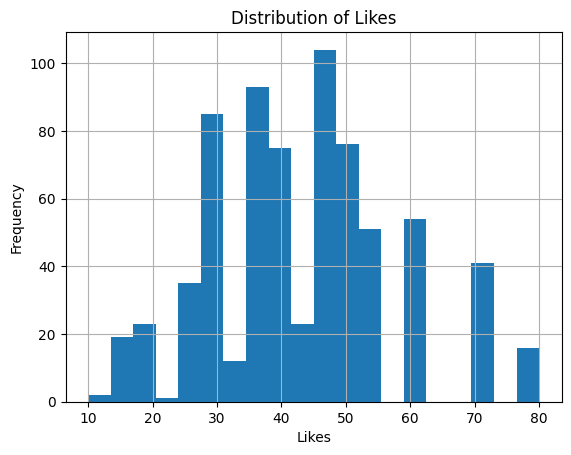

In [14]:
import matplotlib.pyplot as plt

# Histogram of Likes
df["Likes"].hist(bins=20)
plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.show()

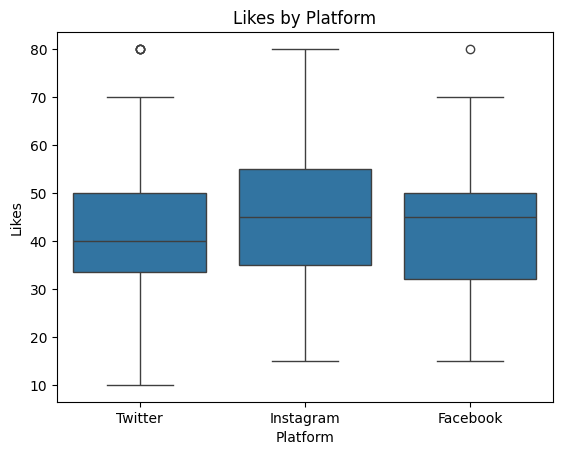

In [15]:
import seaborn as sns

# Boxplot of Likes across different platforms
sns.boxplot(x="Platform", y="Likes", data=df)
plt.title("Likes by Platform")
plt.show()

          Retweets    Likes
Retweets   1.00000  0.99847
Likes      0.99847  1.00000


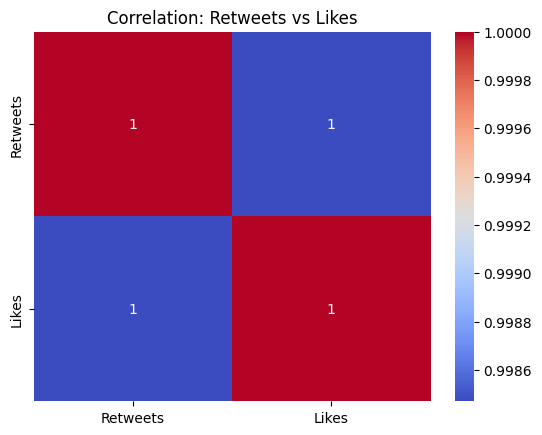

In [16]:
# Correlation matrix for numeric columns
correlation = df[["Retweets", "Likes"]].corr()
print(correlation)

# Visualize it as a heatmap
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation: Retweets vs Likes")
plt.show()